In [2]:
%cd ~/
!git clone https://github.com/RudenkoBogdan/theory_nn.git
%cd theory_nn/california_housing
import sys
import os

/root
Cloning into 'theory_nn'...
remote: Enumerating objects: 63, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 63 (delta 12), reused 61 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (63/63), 39.26 KiB | 5.61 MiB/s, done.
Resolving deltas: 100% (12/12), done.
/root/theory_nn/california_housing


In [3]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from src import dataset, scaler

In [14]:
data = dataset.Data()
scaler = scaler.Scaler()
X_train, X_test, y_train, y_test = data.split()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

AttributeError: 'Scaler' object has no attribute 'Scaler'

In [ ]:
class Regressor:
    def __init__(self,
                 learning_rate=8e-4,
                 epochs = 2000,
                 metric = 'mse',
                 depth = 4,
                 width = 64,
                 activation_func = 'relu',
                 loss_func = 'mse',
                 weight_decay = 1e-5,
                 random_seed = 42):
        
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.metric = metric
        self.depth = depth
        self.width = width
        self.activation_func = activation_func
        self.loss_func = loss_func
        self.weight_decay = weight_decay

        self.weights = None 
        self.bias = None 
        self.activation = None
        self.loss = None
        self.grad = None
        self.cache = None
        self.history = None

        self.rng = np.random.default_rng(random_seed)

    def _init_weights(self):
        self.weights = []
        self.bias = []
        scale = np.sqrt(2.0 / 8)
        width = self.width
        self.weights.append(self.rng.normal(0.0, scale, size=(8, self.width)))
        self.bias.append(np.zeros((1, self.width)))
        for _ in range(self.depth - 2):
            scale = np.sqrt(2.0 / self.width)
            self.weights.append(self.rng.normal(0.0, scale, size=(self.width, self.width)))
            self.bias.append(np.zeros((1, self.width)))
        scale = np.sqrt(1.0 / self.width)
        self.weights.append(self.rng.normal(0.0, scale, size=(self.width, 1)))
        self.bias.append(np.zeros((1, 1)))
        return self
    
    def relu(self, x):
        return np.maximum(0, x)
    
    def relu_grad(self, x):
        result = np.zeros_like(x)
        result[x > 0] = 1
        return result

    def leaky_relu(self, x, a=0.1):
        return np.maximum(x, a * x)
    
    def leaky_relu_grad(self, x, a=0.1):
        result = np.ones_like(x)
        result[x <= 0] = a
        return result

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))
    
    def sigmoid_grad(self, x):
        sigma = self.sigmoid(x)
        return sigma * (1 - sigma)
    
    def _set_activation(self):
        name = self.activation_func
        if name == 'relu':
            self.activation = self.relu
            self.activation_grad = self.relu_grad
        elif name == 'leaky_relu':
            self.activation = self.leaky_relu
            self.activation_grad = self.leaky_relu_grad
        else:
            self.activation = self.sigmoid
            self.activation_grad = self.sigmoid_grad

    def mse(self, y, y_pred):
        return np.mean((y - y_pred)**2)
    
    def mae(self, y, y_pred):
        return np.mean(np.abs(y - y_pred))
    
    def rmse(self, y, y_pred):
        return np.sqrt(self.mse(y, y_pred))
    
    def _set_loss(self):
        name = self.loss_func
        if name == 'mse':
            self.loss = self.mse
        elif name == 'mae':
            self.loss = self.mae
        else:
            self.loss = self.rmse
    
    def _output_delta(self, output, y):
        n = output.shape[0]
        if self.loss_func == 'mse':
            return 2 * (output - y) / n
        elif self.loss_func == 'mae':
            return np.sign(output - y) / n
        else:
            rmse_val = self.rmse(y, output)
            return (output - y) / (n * rmse_val)

    def forward(self, X):
        self.cache = []
        input = X
        
        for i in range(len(self.weights)):
            z = input @ self.weights[i] + self.bias[i]
            a = self.activation(z)
            self.cache.append((z, a))
            input = a
            
        return a

    def backward(self, X, y, output):
        delta = self._output_delta(output, y)

        for i in reversed(range(len(self.weights))):
            if i == 0:
                a_prev = X
            else:
                a_prev = self.cache[i-1][1]

            w = self.weights[i]
            b = self.bias[i]
            wd = self.weight_decay
            lr = self.learning_rate

            dw = a_prev.T @ delta
            db = np.sum(delta, axis=0, keepdims=True)

            self.weights[i] = (1 - wd * lr) * w - lr * dw
            self.bias[i] =  (1 - wd * lr) * b - lr * db

            if i > 0:
                z_prev = self.cache[i-1][0]
                delta = delta @ self.weights[i].T * self.activation_grad(z_prev)


    def fit(self, X_train, y_train):
        self._init_weights()
        self._set_activation()
        self._set_loss()

        X_train = np.asarray(X_train, dtype=np.float32)
        y_train = np.asarray(y_train, dtype=np.float32).reshape(-1, 1)

        self.history = []

        for epoch in range(self.epochs):
            output = self.forward(X_train)

            loss = self.loss(y_train, output)
            self.history.append(loss)

            self.backward(X_train, y_train, output)

            if epoch % 50 == 0:
                print("=" * 8)
                print('Epoch', epoch, '\nLoss', loss)

        return self.history
    
    def predict(self, X):
        calc = X
        for i in range(len(self.weights)):
            z = calc @ self.weights[i] + self.bias[i]
            calc = self.activation(z)
        return calc

In [39]:
model = Regressor()
nn_history = model.fit(X_train, y_train)

Epoch 0 
Loss 5.0596763157794795
Epoch 50 
Loss 1.1821728856015734
Epoch 100 
Loss 0.9515707151695763
Epoch 150 
Loss 0.8713760842716417
Epoch 200 
Loss 0.8329774607457989
Epoch 250 
Loss 0.8088156082295015
Epoch 300 
Loss 0.7902147482584799
Epoch 350 
Loss 0.7741549565914742
Epoch 400 
Loss 0.7596842078608802
Epoch 450 
Loss 0.7463763061433788
Epoch 500 
Loss 0.7340041033339568
Epoch 550 
Loss 0.7224511317091579
Epoch 600 
Loss 0.7116248861635709
Epoch 650 
Loss 0.7014251181701109
Epoch 700 
Loss 0.6917950749903465
Epoch 750 
Loss 0.6826833133675527
Epoch 800 
Loss 0.6740367839701736
Epoch 850 
Loss 0.6658034562799732
Epoch 900 
Loss 0.6579647220849173
Epoch 950 
Loss 0.6504934524908166
Epoch 1000 
Loss 0.6433712946422981
Epoch 1050 
Loss 0.6365455227182263
Epoch 1100 
Loss 0.6299884008865904
Epoch 1150 
Loss 0.6236644857110771
Epoch 1200 
Loss 0.6175644578325516
Epoch 1250 
Loss 0.611672427490941
Epoch 1300 
Loss 0.6059731720786495
Epoch 1350 
Loss 0.6004742882559085
Epoch 1400 
Loss

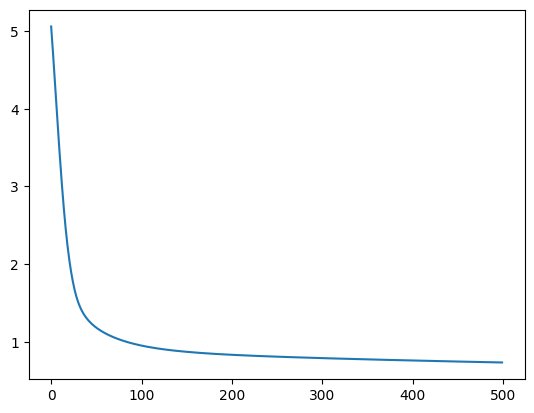

In [32]:
import matplotlib.pyplot as plt

plt.plot(range(len(model.history)), model.history)

In [33]:
from src import linear_regression

LR = linear_regression.LinearRegression()
history = LR.fit(X_train, y_train)

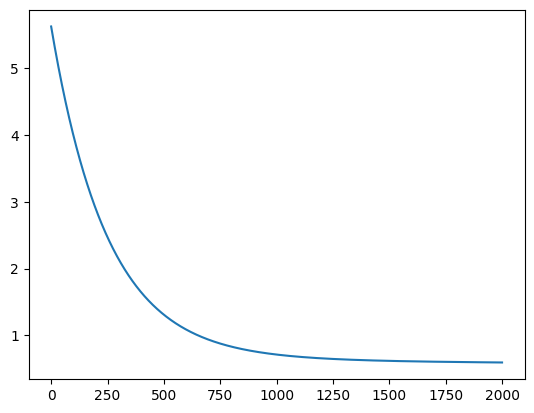

In [34]:
plt.plot(range(len(history)), history)

In [40]:
history[-1]

np.float64(0.5951057151374624)

In [58]:
nn_predict = np.asarray(model.predict(X_test), dtype=np.float32).reshape(-1, 1)
lr_predict = np.asarray(LR.predict(X_test), dtype=np.float32).reshape(-1, 1)
y_test = np.asarray(y_test, dtype=np.float32).reshape(-1, 1)

In [62]:
d_nn = np.sum((y_test - nn_predict)**2)
d_rl = np.sum((y_test - lr_predict)**2)

In [63]:
print(d_nn)
print(d_rl)

2323.201
2506.2795
